In [2]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="gpt-oss:120b-cloud")
print('Model is ready')

Model is ready


In [3]:
from typing import TypedDict

class MultiAgentState(TypedDict):
    query: str
    research_result: str
    math_result: str
    next_agent: str
    final_answer: str

In [4]:
def research_agent(state: MultiAgentState):

    query = state["query"]

    prompt = f"""
    You are a research agent.

    Analyze the following user query and provide
    useful factual information.

    User query:
    {query}

    Give a concise research summary.
    """

    response = model.invoke(prompt)

    return {
        "research_result": response.content
    }

def math_agent(state: MultiAgentState):

    query = state["query"]

    prompt = f"""
    You are a mathematics agent.

    Look at the following user query.

    If calculations are required, perform them carefully.
    Show the calculation clearly.

    User query:
    {query}
    """

    response = model.invoke(prompt)

    return {
        "math_result": response.content
    }

def final_agent(state: MultiAgentState):

    query = state["query"]

    research = state["research_result"]

    math = state["math_result"]

    prompt = f"""
    You are the final response agent.

    Answer the user's original question using the
    information provided by the other agents.

    User question:
    {query}

    Research agent result:
    {research}

    Math agent result:
    {math}

    Combine the relevant information into one clear
    and accurate final answer.

    Do not mention the internal agents.
    """

    response = model.invoke(prompt)

    return {
        "final_answer": response.content
    }

def supervisor(state: MultiAgentState):

    prompt = f"""
    You are a supervisor coordinating multiple agents.

    User query:
    {state["query"]}

    Available agents:

    1. research_agent
    Handles research and factual information.

    2. math_agent
    Handles mathematical calculations.

    3. final_agent
    Produces the final response.

    Research result:
    {state["research_result"]}

    Math result:
    {state["math_result"]}

    Choose the next agent.

    Return ONLY one of:

    research_agent
    math_agent
    final_agent
    """

    response = model.invoke(prompt)

    return {
        "next_agent": response.content.strip()
    }

def route_supervisor(state: MultiAgentState):
    return state["next_agent"]

print('All nodes are ready')

All nodes are ready


Graph is ready


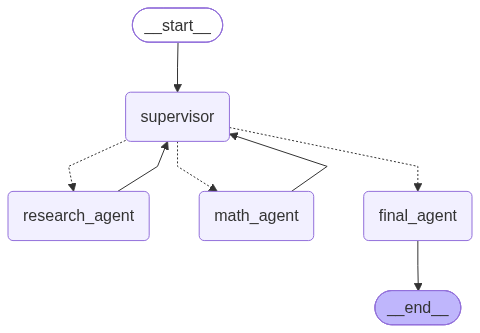

In [5]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(MultiAgentState)

builder.add_node("supervisor", supervisor)
builder.add_node("research_agent", research_agent)

builder.add_node("math_agent", math_agent)

builder.add_node("final_agent", final_agent)
builder.add_edge(
    START,
    "supervisor"
)

builder.add_conditional_edges(
    "supervisor",
    route_supervisor,
    {
        "research_agent": "research_agent",
        "math_agent": "math_agent",
        "final_agent": "final_agent"
    }
)


builder.add_edge(
    "research_agent",
    "supervisor"
)

builder.add_edge(
    "math_agent",
    "supervisor"
)

builder.add_edge(
    "supervisor",
    END
)
graph = builder.compile()
print('Graph is ready')
graph

In [8]:
result = graph.invoke({
    "query": "What is the population growth of India and what is 25% of 480?",
    "research_result": "",
    "math_result": "",
    "final_answer": ""
})
print(result["final_answer"])

**India’s Population Growth**

- **Current population (2023 estimate):** about **1.43 billion** people.  
- **Annual growth rate (2022‑2023):** roughly **0.8 % per year**, which adds about **11 million people each year**.  
- **Recent trend:** The population rose from roughly **1.21 billion in 2011** to **1.43 billion in 2023**, an increase of about **220 million** (≈ 18 % growth over 12 years). The growth rate has slowed compared with earlier decades.  
- **Future outlook:** If the current pace continues, India is expected to reach around **1.5 billion by 2030** and will become the world’s most‑populous country (surpassing China) around **2024**.

**25 % of 480**

\[
25\% \times 480 = 0.25 \times 480 = \mathbf{120}
\]

So, a quarter of 480 equals **120**.
